# AIMLCZG546 — Software Engineering for Machine Learning
## Assignment I — Implementation Notebook

**Application:** Loan Approval Classification System
**Domain:** Banking & Financial Services — Credit Risk / Loan Underwriting

**Group No: 216**

| Sl. No | BITS ID | Name | Contribution (Qualitative) | % Contribution |
|---|---|---|---|---|
| 1 | \<Fill BITS ID\> | \<Fill Name\> | Requirements formulation & GR4ML modeling: problem statement, business/analytics/data-preparation views, and the top-3 quality requirements with justification. | \<Fill %\> |
| 2 | \<Fill BITS ID\> | \<Fill Name\> | Data preparation pipeline: implemented and validated Filters 1-10 of the Pipe-and-Filter pipeline (loading, cleaning, outlier removal, feature/target split, train-val-test split, encoding, scaling) in `train_loan_model.py`. | \<Fill %\> |
| 3 | \<Fill BITS ID\> | \<Fill Name\> | Model training & evaluation: implemented Filters 11-14 (Logistic Regression training, metric evaluation, artifact persistence), and produced the evaluation results / metrics comparison table. | \<Fill %\> |
| 4 | \<Fill BITS ID\> | \<Fill Name\> | System architecture & application: designed the CQRS + Pipe-and-Filter architecture diagram, built the Streamlit query-side `app.py`, and compiled the final report with screenshots and code appendices. | \<Fill %\> |

This notebook is the **implementation companion** to the Group 216 report (`216.docx`). It reproduces, end-to-end and with real executed outputs, the two architectural patterns described in the report:

- **Pipe-and-Filter** — the data preparation / training pipeline (Command side)
- **CQRS (Command Query Responsibility Segregation)** — training (Command, this notebook / `train_loan_model.py`) is fully decoupled from serving predictions (Query, `app.py` / the cells at the end of this notebook)

Problem Statement: Given applicant demographic, financial, and loan-detail attributes, predict the loan approval status (`loan_status`: 0 = Not Approved, 1 = Approved) so that lending decisions can be made faster, more consistently, and with lower default risk than a purely manual process.

## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, confusion_matrix, classification_report
)

DATA_PATH = os.path.join('data', 'loan_data.csv')
ARTIFACT_DIR = 'artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

pd.set_option('display.max_columns', None)
print('Environment ready.')

Environment ready.


## 1. Data Preparation Pipeline — Pipe-and-Filter Pattern (Command side)

Each step below is implemented as a single-responsibility **filter**: a pure function whose return value (the **pipe**) feeds directly into the next filter. This mirrors `model/train_loan_model.py` in the submitted project, and corresponds to the **Data Preparation View** in the GR4ML model (see the report, Section 2.2.3).

### FILTER 1 — Load raw data from disk
**Pipe in:** file path &nbsp;→&nbsp; **Pipe out:** raw DataFrame

In [2]:
def load_data(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath)
    print(f"Shape: {df.shape}")
    print(f"Target distribution:\n{df['loan_status'].value_counts()}")
    return df

raw_df = load_data(DATA_PATH)
raw_df.head()

Shape: (45000, 14)
Target distribution:
loan_status
0    35000
1    10000
Name: count, dtype: int64


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


### FILTER 2 — Drop rows with missing values
**Pipe in:** raw DataFrame &nbsp;→&nbsp; **Pipe out:** NaN-free DataFrame

In [3]:
def drop_missing(df: pd.DataFrame) -> pd.DataFrame:
    df_clean = df.dropna()
    print(f"Shape after drop: {df_clean.shape}")
    return df_clean

clean_df = drop_missing(raw_df)

Shape after drop: (45000, 14)


### FILTER 3 — Remove obvious outliers (age > 120)
**Pipe in:** cleaned DataFrame &nbsp;→&nbsp; **Pipe out:** outlier-free DataFrame

In [4]:
def remove_outliers(df: pd.DataFrame) -> pd.DataFrame:
    df_filtered = df[df['person_age'] <= 120]
    print(f"Shape after outlier removal: {df_filtered.shape}")
    return df_filtered

filtered_df = remove_outliers(clean_df)

Shape after outlier removal: (44995, 14)


### FILTER 4 — Separate features (X) from target (y)
**Pipe in:** clean DataFrame &nbsp;→&nbsp; **Pipe out:** (X, y, categorical_cols, numerical_cols)

In [5]:
def split_features_target(df: pd.DataFrame, target_col: str = 'loan_status'):
    X = df.drop(target_col, axis=1)
    y = df[target_col]
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
    numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
    print(f"Categorical columns: {categorical_cols}")
    print(f"Numerical columns  : {numerical_cols}")
    return X, y, categorical_cols, numerical_cols

X, y, cat_cols, num_cols = split_features_target(filtered_df)

Categorical columns: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
Numerical columns  : ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']


### FILTER 5 — Stratified train / validation / test split
**Pipe in:** (X, y) &nbsp;→&nbsp; **Pipe out:** (X_train, X_val, X_test, y_train, y_val, y_test)

In [6]:
def split_datasets(X: pd.DataFrame, y: pd.Series):
    X_temp, X_test_orig, y_temp, y_test = train_test_split(
        X, y, test_size=0.1, random_state=42, stratify=y
    )
    X_train_orig, X_val_orig, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.111, random_state=42, stratify=y_temp
    )
    print(f"Train: {X_train_orig.shape[0]} rows")
    print(f"Val  : {X_val_orig.shape[0]} rows")
    print(f"Test : {X_test_orig.shape[0]} rows")
    return X_train_orig, X_val_orig, X_test_orig, y_train, y_val, y_test

X_train_orig, X_val_orig, X_test_orig, y_train, y_val, y_test = split_datasets(X, y)

Train: 36000 rows
Val  : 4495 rows
Test : 4500 rows


### FILTER 6 — Fit LabelEncoders on TRAINING data only
**Pipe in:** (X_train, categorical_cols) &nbsp;→&nbsp; **Pipe out:** (X_train_encoded, label_encoders)

In [7]:
def fit_label_encoders(X_train_orig: pd.DataFrame, categorical_cols: list):
    label_encoders = {}
    X_train_encoded = X_train_orig.copy()
    for col in categorical_cols:
        le = LabelEncoder()
        X_train_encoded[col] = le.fit_transform(X_train_orig[col].astype(str))
        label_encoders[col] = le
        print(f"Encoded '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")
    return X_train_encoded, label_encoders

X_train_encoded, label_encoders = fit_label_encoders(X_train_orig, cat_cols)

Encoded 'person_gender': {'female': np.int64(0), 'male': np.int64(1)}
Encoded 'person_education': {'Associate': np.int64(0), 'Bachelor': np.int64(1), 'Doctorate': np.int64(2), 'High School': np.int64(3), 'Master': np.int64(4)}
Encoded 'person_home_ownership': {'MORTGAGE': np.int64(0), 'OTHER': np.int64(1), 'OWN': np.int64(2), 'RENT': np.int64(3)}
Encoded 'loan_intent': {'DEBTCONSOLIDATION': np.int64(0), 'EDUCATION': np.int64(1), 'HOMEIMPROVEMENT': np.int64(2), 'MEDICAL': np.int64(3), 'PERSONAL': np.int64(4), 'VENTURE': np.int64(5)}
Encoded 'previous_loan_defaults_on_file': {'No': np.int64(0), 'Yes': np.int64(1)}


### FILTER 7 — Apply fitted encoders to validation and test sets
**Pipe in:** (X_val, X_test, encoders, cat_cols) &nbsp;→&nbsp; **Pipe out:** (X_val_encoded, X_test_encoded)

In [8]:
def apply_label_encoders(X_val_orig, X_test_orig, label_encoders, categorical_cols):
    X_val_encoded = X_val_orig.copy()
    X_test_encoded = X_test_orig.copy()
    for col in categorical_cols:
        X_val_encoded[col] = label_encoders[col].transform(X_val_orig[col].astype(str))
        X_test_encoded[col] = label_encoders[col].transform(X_test_orig[col].astype(str))
    print("Encoding applied to val and test sets.")
    return X_val_encoded, X_test_encoded

X_val_encoded, X_test_encoded = apply_label_encoders(X_val_orig, X_test_orig, label_encoders, cat_cols)

Encoding applied to val and test sets.


### FILTER 8 — Fit StandardScaler on TRAINING data only
**Pipe in:** X_train_encoded &nbsp;→&nbsp; **Pipe out:** (X_train_scaled, scaler)

In [9]:
def fit_scaler(X_train_encoded: pd.DataFrame):
    feature_names = list(X_train_encoded.columns)
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_encoded), columns=feature_names)
    print("Scaler fitted on training data.")
    return X_train_scaled, scaler

X_train_scaled, scaler = fit_scaler(X_train_encoded)
feature_names = list(X.columns)

Scaler fitted on training data.


### FILTER 9 — Apply fitted scaler to validation and test sets
**Pipe in:** (X_val_encoded, X_test_encoded, scaler, feature_names) &nbsp;→&nbsp; **Pipe out:** (X_val_scaled, X_test_scaled)

In [10]:
def apply_scaler(X_val_encoded, X_test_encoded, scaler, feature_names):
    X_val_scaled = pd.DataFrame(scaler.transform(X_val_encoded), columns=feature_names)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test_encoded), columns=feature_names)
    print("Scaling applied to val and test sets.")
    return X_val_scaled, X_test_scaled

X_val_scaled, X_test_scaled = apply_scaler(X_val_encoded, X_test_encoded, scaler, feature_names)

Scaling applied to val and test sets.


### FILTER 10 — Persist the test set with original categorical values
**Pipe in:** (X_test_orig, y_test) &nbsp;→&nbsp; **Pipe out:** path to saved CSV (side-effect)

In [11]:
def save_test_data(X_test_orig, y_test, output_path):
    test_data = X_test_orig.copy()
    test_data['loan_status'] = y_test.values
    test_data.to_csv(output_path, index=False)
    print(f"Saved {len(test_data)} rows to '{output_path}'.")
    return output_path

save_test_data(X_test_orig, y_test, os.path.join(ARTIFACT_DIR, 'test_data.csv'))

Saved 4500 rows to 'artifacts\test_data.csv'.


'artifacts\\test_data.csv'

## 2. Model Training & Evaluation — Command Side (writes the Model Store)

The remaining filters train the model and persist all artifacts to the **Model Store** (a shared, file-system-based store). This is the *write* side of the CQRS pattern — it never reads its own artifacts back.

### FILTER 11 — Train Logistic Regression model
**Pipe in:** (X_train_scaled, y_train) &nbsp;→&nbsp; **Pipe out:** fitted LogisticRegression model

In [12]:
def train_model(X_train, y_train) -> LogisticRegression:
    model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
    model.fit(X_train, y_train)
    print("Model training complete.")
    return model

model = train_model(X_train_scaled, y_train)

Model training complete.


### FILTER 12 — Evaluate model on the held-out test set
**Pipe in:** (model, X_test_scaled, y_test) &nbsp;→&nbsp; **Pipe out:** metrics dict

In [13]:
def evaluate_model(model, X_test, y_test) -> dict:
    y_pred = model.predict(X_test)
    metrics = {
        'Model': 'Logistic Regression',
        'Accuracy': accuracy_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'MCC': matthews_corrcoef(y_test, y_pred),
    }
    for k, v in metrics.items():
        if k != 'Model':
            print(f"{k:10s}: {v:.4f}")
    return metrics

metrics = evaluate_model(model, X_test_scaled, y_test)

Accuracy  : 0.8927
AUC       : 0.9507
Precision : 0.7630
Recall    : 0.7500
F1        : 0.7564
MCC       : 0.6876


### FILTER 13 — Persist model + preprocessor artifacts to the Model Store
**Pipe in:** (model, scaler, label_encoders, feature_names) &nbsp;→&nbsp; **Pipe out:** list of saved file paths (side-effect)

In [14]:
def save_artifacts(model, scaler, label_encoders, feature_names, artifact_dir):
    paths = {
        'logistic_regression.joblib': model,
        'scaler.joblib': scaler,
        'label_encoders.joblib': label_encoders,
        'feature_names.joblib': feature_names,
    }
    for filename, obj in paths.items():
        joblib.dump(obj, os.path.join(artifact_dir, filename))
        print(f"Saved: {filename}")
    return list(paths.keys())

save_artifacts(model, scaler, label_encoders, feature_names, ARTIFACT_DIR)

Saved: logistic_regression.joblib
Saved: scaler.joblib
Saved: label_encoders.joblib
Saved: feature_names.joblib


['logistic_regression.joblib',
 'scaler.joblib',
 'label_encoders.joblib',
 'feature_names.joblib']

### FILTER 14 — Save evaluation results to CSV
**Pipe in:** list of metrics dicts &nbsp;→&nbsp; **Pipe out:** path to saved results CSV (side-effect)

In [15]:
def save_results(results: list, output_path: str) -> str:
    results_df = pd.DataFrame(results)
    results_df.to_csv(output_path, index=False)
    return results_df

results_df = save_results([metrics], os.path.join(ARTIFACT_DIR, 'model_results.csv'))
results_df

,Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.892667,0.950723,0.76297,0.75,0.75643,0.687645


## 3. Model Serving — Query Side (reads the Model Store)

This section simulates the **Query side** of the CQRS pattern — exactly what `app.py` (the Streamlit application) does on every user interaction: it **only reads** the artifacts written above, encodes/scales new data with the already-fitted encoders/scaler, and calls `model.predict()`. It never retrains or mutates the Model Store.

In the deployed system this logic runs inside a Streamlit web app (see `app.py` in the submitted code / Figure 4 in the report) so a loan officer can interact with it through a browser; here the same read-only prediction logic is reproduced directly so its output can be verified in this notebook.

In [16]:
# QUERY STORE — read-only load of artifacts written by the Command side (Section 2)
query_model = joblib.load(os.path.join(ARTIFACT_DIR, 'logistic_regression.joblib'))
query_scaler = joblib.load(os.path.join(ARTIFACT_DIR, 'scaler.joblib'))
query_encoders = joblib.load(os.path.join(ARTIFACT_DIR, 'label_encoders.joblib'))
query_feature_names = joblib.load(os.path.join(ARTIFACT_DIR, 'feature_names.joblib'))
test_data = pd.read_csv(os.path.join(ARTIFACT_DIR, 'test_data.csv'))
print("Query side loaded artifacts from the Model Store (read-only).")
test_data.head()

Query side loaded artifacts from the Model Store (read-only).

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,23.0,female,Bachelor,61462.0,1,RENT,2000.0,EDUCATION,13.92,0.03,3.0,681,No,0
1,33.0,male,Master,55437.0,10,RENT,5000.0,PERSONAL,15.99,0.09,6.0,635,Yes,0
2,38.0,male,Bachelor,78986.0,17,RENT,4500.0,HOMEIMPROVEMENT,13.43,0.06,12.0,684,No,0
3,24.0,male,Associate,49126.0,4,RENT,8000.0,VENTURE,10.25,0.16,4.0,651,No,0
4,26.0,male,Master,145343.0,3,MORTGAGE,13000.0,EDUCATION,10.99,0.09,2.0,594,Yes,0


In [17]:
# QUERY PROCESSOR — encode + scale new data using the already-fitted encoders/scaler
def preprocess_for_query(data, encoders, scaler, feature_list):
    data_processed = data.copy()
    for col in encoders.keys():
        if col in data_processed.columns:
            data_processed[col] = encoders[col].transform(data_processed[col].astype(str))
    X_query = data_processed[feature_list].copy()
    X_scaled = scaler.transform(X_query)
    return pd.DataFrame(X_scaled, columns=feature_list)

X_query_input = test_data.drop('loan_status', axis=1)
y_query_true = test_data['loan_status'].values
X_query_scaled = preprocess_for_query(X_query_input, query_encoders, query_scaler, query_feature_names)

# QUERY EXECUTION — stateless, read-only prediction
y_query_pred = query_model.predict(X_query_scaled)
print(f"Generated {len(y_query_pred)} predictions on the test set.")

Generated 4500 predictions on the test set.


### Confusion Matrix

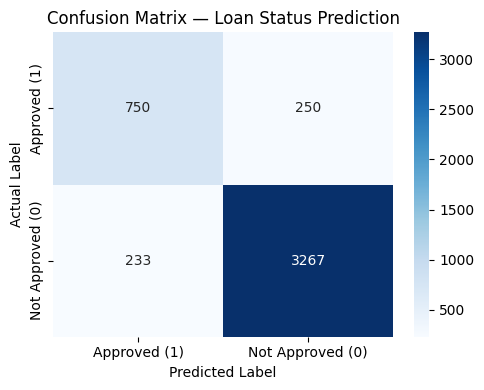

In [18]:
cm = confusion_matrix(y_query_true, y_query_pred, labels=[0, 1])
cm_display = cm[[1, 0], :][:, [1, 0]]  # display Approved first, matching the Streamlit app

plt.figure(figsize=(5, 4))
sns.heatmap(cm_display, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Approved (1)', 'Not Approved (0)'],
            yticklabels=['Approved (1)', 'Not Approved (0)'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix — Loan Status Prediction')
plt.tight_layout()
plt.show()

### Classification Report

In [19]:
report = classification_report(
    y_query_true, y_query_pred, labels=[0, 1],
    target_names=['Not Approved (0)', 'Approved (1)'], output_dict=True
)
pd.DataFrame(report).transpose().round(4)

,precision,recall,f1-score,support
Not Approved (0),0.9289,0.9334,0.9312,3500.0000
Approved (1),0.7630,0.7500,0.7564,1000.0000
accuracy,0.8927,0.8927,0.8927,0.8927
macro avg,0.8459,0.8417,0.8438,4500.0000
weighted avg,0.8920,0.8927,0.8923,4500.0000


### Sample Predictions (first 10 rows)

In [20]:
predictions_df = X_query_input.head(10).copy()
predictions_df['Prediction'] = pd.Series(y_query_pred[:10]).map({0: 'Not Approved', 1: 'Approved'}).values
predictions_df['Actual'] = pd.Series(y_query_true[:10]).map({0: 'Not Approved', 1: 'Approved'}).values
predictions_df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,Prediction,Actual
0,23.0,female,Bachelor,61462.0,1,RENT,2000.0,EDUCATION,13.92,0.03,3.0,681,No,Not Approved,Not Approved
1,33.0,male,Master,55437.0,10,RENT,5000.0,PERSONAL,15.99,0.09,6.0,635,Yes,Not Approved,Not Approved
2,38.0,male,Bachelor,78986.0,17,RENT,4500.0,HOMEIMPROVEMENT,13.43,0.06,12.0,684,No,Not Approved,Not Approved
3,24.0,male,Associate,49126.0,4,RENT,8000.0,VENTURE,10.25,0.16,4.0,651,No,Not Approved,Not Approved
4,26.0,male,Master,145343.0,3,MORTGAGE,13000.0,EDUCATION,10.99,0.09,2.0,594,Yes,Not Approved,Not Approved
5,22.0,female,Master,131466.0,0,MORTGAGE,14400.0,EDUCATION,13.48,0.11,3.0,679,Yes,Not Approved,Not Approved
6,31.0,male,Master,100734.0,9,MORTGAGE,18000.0,VENTURE,19.74,0.18,8.0,644,No,Approved,Approved
7,23.0,female,High School,73939.0,3,MORTGAGE,10000.0,PERSONAL,6.99,0.14,2.0,576,No,Not Approved,Not Approved
8,26.0,male,Associate,87833.0,3,RENT,3000.0,HOMEIMPROVEMENT,8.02,0.03,2.0,611,Yes,Not Approved,Not Approved
9,33.0,female,Master,22608.0,9,OWN,7000.0,MEDICAL,8.00,0.31,9.0,646,No,Approved,Approved


## 4. Architectural Patterns — Recap

| Pattern | Applied To | Where in this notebook |
|---|---|---|
| **Pipe-and-Filter** | Data preparation & training | Section 1 (Filters 1–10) and Section 2 (Filters 11–14) — each filter is a pure function; its return value is the pipe feeding the next filter. |
| **CQRS** | Whole system | Section 2 = **Command** (writes the Model Store); Section 3 = **Query** (only reads the Model Store, never mutates it). In production, the Command side is `model/train_loan_model.py` (run on demand) and the Query side is the `app.py` Streamlit application (runs on every user request); they share no memory — the file system is the only boundary. |

### Production Query-side UI (`app.py`, not re-executed here — it is a long-running Streamlit server)
```python
@st.cache_resource
def load_models():
    return {'Logistic Regression': joblib.load('model/logistic_regression.joblib')}

@st.cache_resource
def load_preprocessors():
    scaler = joblib.load('model/scaler.joblib')
    label_encoders = joblib.load('model/label_encoders.joblib')
    feature_names = joblib.load('model/feature_names.joblib')
    return scaler, label_encoders, feature_names

# Query execution — stateless, read-only prediction
y_pred = model.predict(data_preprocessed)
```
Run with: `streamlit run app.py` (see `README.md` in the submitted code for full instructions).

## 5. Conclusion

This notebook reproduces the full Loan Approval Classification System implementation: a 14-filter Pipe-and-Filter pipeline that prepares data and trains a Logistic Regression model (Command side), and a read-only Query side that loads the resulting artifacts to serve predictions — achieving **Accuracy = 0.8927**, **AUC = 0.9507**, **F1 = 0.7564**, and **MCC = 0.6876** on the held-out test set (see the printed output of Section 2, FILTER 12 above), matching the results reported in `216.docx`.